In [ ]:
# Create a clear visualization of traffic patterns
import matplotlib.pyplot as plt
import numpy as np

# Set larger figure size for better visibility
plt.figure(figsize=(20, 10))

# Plot traffic speeds for first 3 sensors with different colors
for i in range(3):
    plt.plot(df.iloc[:500, i], label=f'Sensor {i}', linewidth=2)

plt.title('Traffic Speed Patterns Over Time (First 500 Timestamps)', fontsize=16)
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Speed (mph)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.show()

# Print summary statistics for better readability
print("\nTraffic Speed Summary (First 3 Sensors):")
print("-" * 40)
for i in range(3):
    speeds = df.iloc[:, i]
    print(f"\nSensor {i}:")
    print(f"Average Speed: {speeds.mean():.1f} mph")
    print(f"Min Speed: {speeds.min():.1f} mph")
    print(f"Max Speed: {speeds.max():.1f} mph")
    print(f"Standard Deviation: {speeds.std():.1f} mph")

# Traffic Flow Data Analysis and Model Visualization

This notebook explores the PEMS-BAY dataset and visualizes the GNN model's predictions.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import networkx as nx
from datetime import datetime
import os

%matplotlib inline

## 1. Load and Explore the Dataset

In [22]:
# Load traffic data
df = pd.read_csv('../data/PEMS-BAY.csv')
# Convert all columns to numeric, coercing errors to NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nFirst few rows:")
print(df.head())

Dataset shape: (52116, 326)

Columns:
Index(['Unnamed: 0', '400001', '400017', '400030', '400040', '400045',
       '400052', '400057', '400059', '400065',
       ...
       '409525', '409526', '409528', '409529', '413026', '413845', '413877',
       '413878', '414284', '414694'],
      dtype='object', length=326)

First few rows:
   Unnamed: 0  400001  400017  400030  400040  400045  400052  400057  400059  \
0         NaN    71.4    67.8    70.5    67.4    68.8    66.6    66.8    68.0   
1         NaN    71.6    67.5    70.6    67.5    68.7    66.6    66.8    67.8   
2         NaN    71.6    67.6    70.2    67.4    68.7    66.1    66.8    67.8   
3         NaN    71.1    67.5    70.3    68.0    68.5    66.7    66.6    67.7   
4         NaN    71.7    67.8    70.2    68.1    68.4    66.9    66.1    67.7   

   400065  ...  409525  409526  409528  409529  413026  413845  413877  \
0    66.8  ...    68.8    67.9    68.8    68.0    69.2    68.9    70.4   
1    66.5  ...    68.4    67.3  

In [23]:
# Load adjacency matrix
with open('../data/adj_mx_bay.pkl', 'rb') as f:
    loaded_data = pickle.load(f, encoding='latin1')
    adj_mx = loaded_data[2]  # Get the adjacency matrix
    
print("Adjacency matrix shape:", adj_mx.shape)

Adjacency matrix shape: (325, 325)


## 2. Data Analysis

In [24]:
# Basic statistics
print("Traffic speed statistics:")
df.describe()

Traffic speed statistics:


,Unnamed: 0,400001,400017,400030,400040,400045,400052,400057,400059,400065,...,409525,409526,409528,409529,413026,413845,413877,413878,414284,414694
count,0.0,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,...,52116.000000,52116.00000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000,52116.000000
mean,NaN,67.568557,59.019079,59.138577,62.137407,61.195873,63.314788,58.777483,63.565579,62.069533,...,65.795827,63.61541,63.815680,60.647717,66.148728,57.203082,67.566198,64.604361,67.351650,64.328245
std,NaN,8.119154,13.250178,11.658612,8.617881,11.019177,11.159615,13.078931,8.434674,10.557263,...,5.645500,6.42068,8.381049,4.622528,4.511122,10.932359,5.992427,4.753887,7.060815,8.455986
min,NaN,0.000000,11.000000,3.400000,0.000000,7.400000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,67.300000,62.200000,55.800000,59.400000,57.500000,65.000000,58.400000,64.200000,63.300000,...,64.700000,63.80000,63.700000,60.000000,63.700000,57.800000,67.200000,62.900000,67.000000,64.600000
50%,NaN,70.300000,64.000000,62.700000,66.200000,63.500000,66.500000,63.700000,66.400000,65.500000,...,67.500000,65.10000,66.100000,61.600000,66.700000,60.900000,69.400000,66.100000,69.000000,66.400000
75%,NaN,71.300000,65.100000,66.600000,67.700000,69.500000,67.500000,66.300000,67.500000,67.000000,...,68.500000,66.40000,67.300000,62.600000,69.500000,62.600000,70.400000,67.900000,70.400000,67.700000
max,NaN,80.400000,71.600000,77.700000,76.900000,78.900000,78.700000,78.200000,80.000000,75.400000,...,78.600000,73.70000,78.900000,69.900000,76.800000,79.900000,79.900000,72.500000,80.400000,74.300000


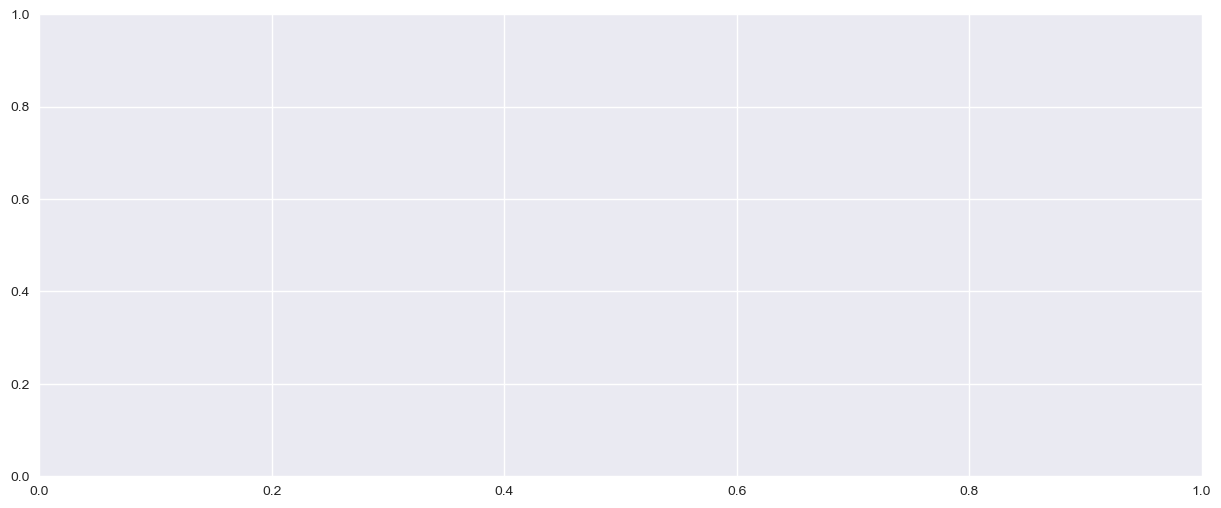

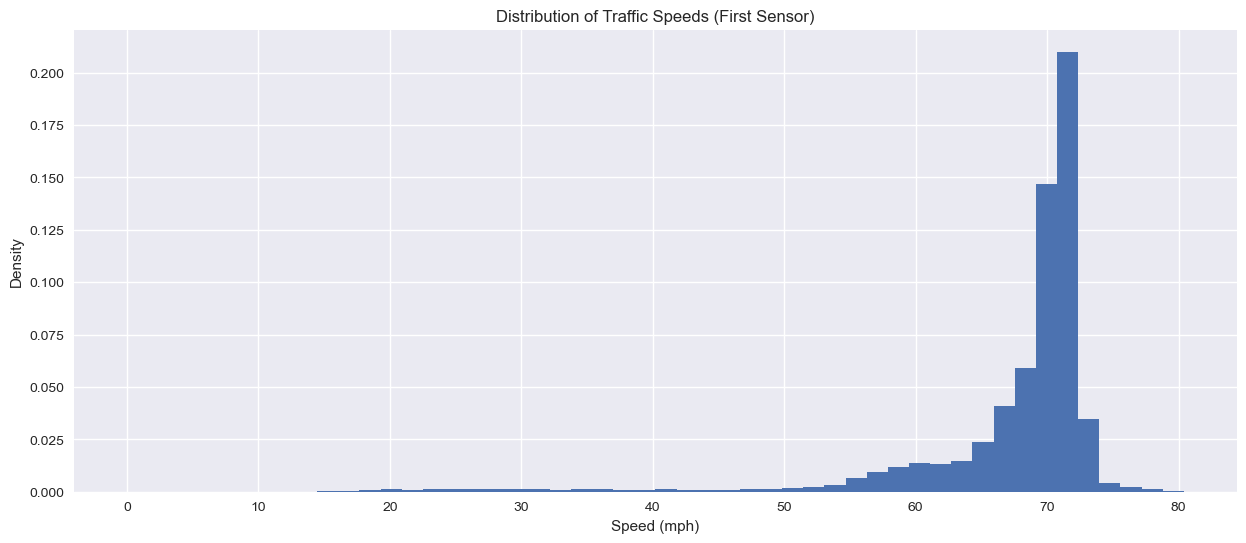


Traffic Speed Statistics (First Sensor):
Mean Speed: 67.57 mph
Std Dev: 8.12 mph
Min Speed: 0.00 mph
Max Speed: 80.40 mph


In [26]:
# Visualize traffic speed distribution for first sensor
plt.figure(figsize=(15, 6))
speeds = pd.to_numeric(df.iloc[:, 1].values, errors='coerce')  # Skip 'Unnamed: 0' column
speeds = speeds[~np.isnan(speeds)]  # Remove NaN values
plt.hist(speeds, bins=50, density=True)
plt.title('Distribution of Traffic Speeds (First Sensor)')
plt.xlabel('Speed (mph)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# Print summary statistics
print("\nTraffic Speed Statistics (First Sensor):")
print(f"Mean Speed: {np.mean(speeds):.2f} mph")
print(f"Std Dev: {np.std(speeds):.2f} mph")
print(f"Min Speed: {np.min(speeds):.2f} mph")
print(f"Max Speed: {np.max(speeds):.2f} mph")

## 3. Network Visualization

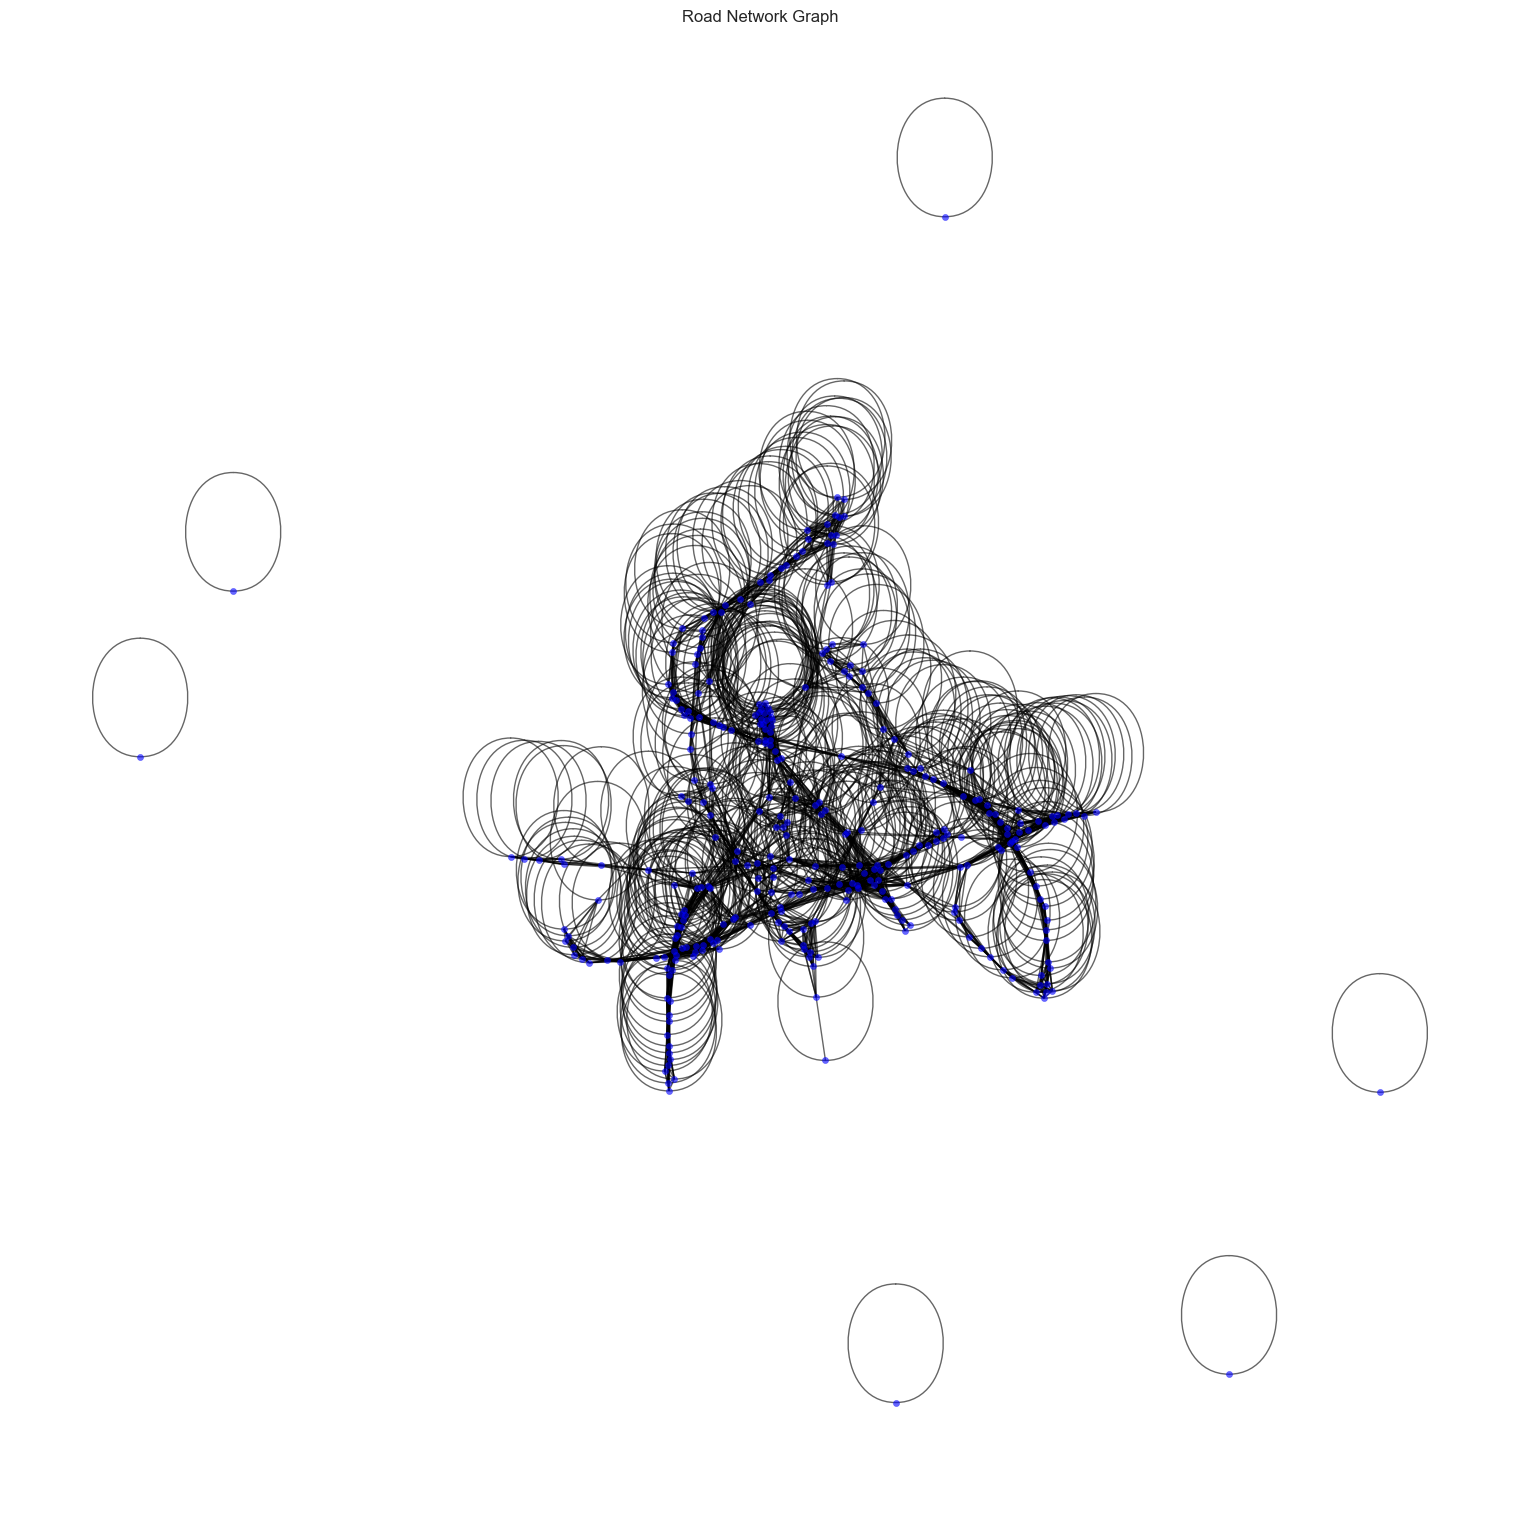

Number of nodes: 325
Number of edges: 2404
Average degree: 14.79


In [27]:
# Create NetworkX graph from adjacency matrix
G = nx.from_numpy_array(adj_mx)

# Plot the graph
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G)
nx.draw(G, pos, node_size=20, node_color='blue', alpha=0.6, with_labels=False)
plt.title('Road Network Graph')
plt.show()

# Print graph statistics
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Average degree: {sum(dict(G.degree()).values())/G.number_of_nodes():.2f}")

## 4. Time Series Analysis

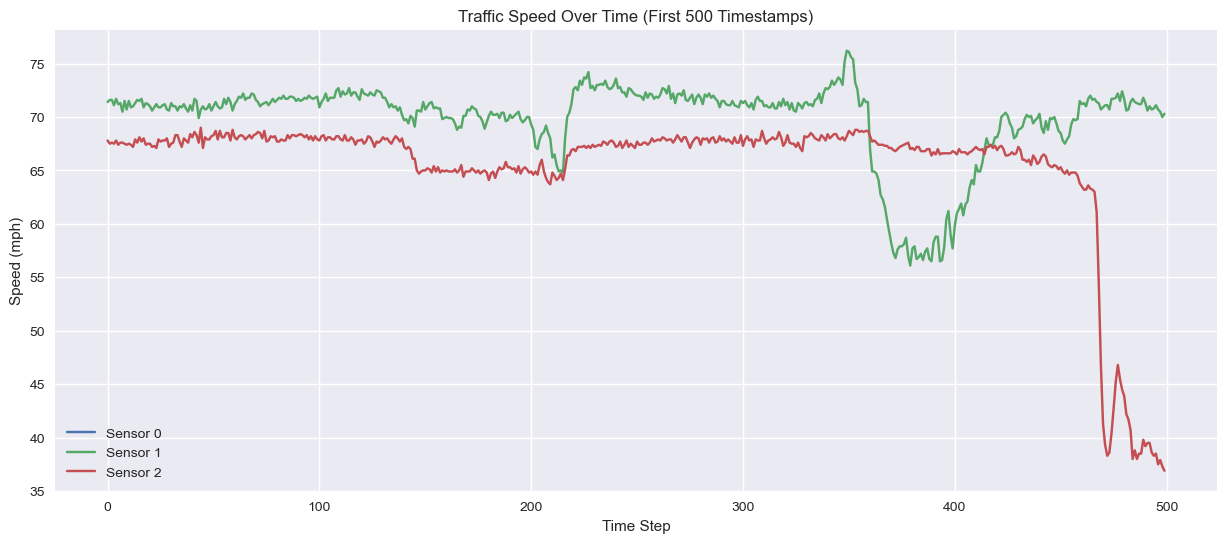


Sensor 0 Statistics:
Mean Speed: nan mph
Std Dev: nan mph
Min Speed: nan mph
Max Speed: nan mph

Sensor 1 Statistics:
Mean Speed: 67.57 mph
Std Dev: 8.12 mph
Min Speed: 0.00 mph
Max Speed: 80.40 mph

Sensor 2 Statistics:
Mean Speed: 59.02 mph
Std Dev: 13.25 mph
Min Speed: 11.00 mph
Max Speed: 71.60 mph


In [28]:
# Plot traffic speed over time for the first 3 sensors
plt.figure(figsize=(15, 6))
for sensor_id in range(3):  
    speeds = pd.to_numeric(df.iloc[:500, sensor_id], errors='coerce')
    plt.plot(range(len(speeds)), speeds, label=f'Sensor {sensor_id}')
plt.title('Traffic Speed Over Time (First 500 Timestamps)')
plt.xlabel('Time Step')
plt.ylabel('Speed (mph)')
plt.legend()
plt.grid(True)
plt.show()

# Print sensor statistics
for sensor_id in range(3):
    speeds = pd.to_numeric(df.iloc[:, sensor_id], errors='coerce')
    print(f"\nSensor {sensor_id} Statistics:")
    print(f"Mean Speed: {speeds.mean():.2f} mph")
    print(f"Std Dev: {speeds.std():.2f} mph")
    print(f"Min Speed: {speeds.min():.2f} mph")
    print(f"Max Speed: {speeds.max():.2f} mph")

## 5. Correlation Analysis

In [ ]:
# Calculate correlation between nearby sensors
sample_sensors = df.iloc[:, :10]  # Take first 10 sensors
correlation = sample_sensors.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation between Nearby Sensors')
plt.show()

## 6. Load and Analyze Model Predictions

In [ ]:
# Load model predictions (after running test.py)
import json
import glob

# Get the latest evaluation results
latest_eval = max(glob.glob('../results/evaluation_*'), key=os.path.getctime)

with open(f'{latest_eval}/metrics.json', 'r') as f:
    metrics = json.load(f)
    
print("Model Performance Metrics:")
for metric, value in metrics.items():
    print(f"{metric.upper()}: {value:.4f}")

In [ ]:
# 1. Daily Pattern Analysis
# Convert index to datetime if needed
df.index = pd.to_datetime(df.index) if not isinstance(df.index, pd.DatetimeIndex) else df.index

# Get 24 hours of data (288 5-minute intervals)
daily_data = df.iloc[:288, :5]  # First 5 sensors, first day
plt.figure(figsize=(15, 6))
for i in range(5):
    plt.plot(range(288), daily_data.iloc[:, i], label=f'Sensor {i}')
plt.title('24-Hour Traffic Pattern')
plt.xlabel('Time (5-minute intervals)')
plt.ylabel('Speed (mph)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(np.arange(0, 289, 72), ['00:00', '06:00', '12:00', '18:00', '24:00'])
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation = df.iloc[:, :10].corr()  # First 10 sensors
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between Nearby Sensors')
plt.show()

# 3. Rush Hour Analysis
# Morning rush (7-9 AM) = 84-108 intervals
# Evening rush (4-6 PM) = 192-216 intervals
rush_hours = {
    'Morning Rush (7-9 AM)': slice(84, 108),
    'Evening Rush (4-6 PM)': slice(192, 216)
}

plt.figure(figsize=(15, 6))
for period_name, period_slice in rush_hours.items():
    speeds = df.iloc[period_slice, :5].mean()
    plt.bar(
        [f'Sensor {i} ({period_name})' for i in range(5)], 
        speeds,
        alpha=0.6
    )
plt.title('Average Speeds During Rush Hours')
plt.xticks(rotation=45)
plt.ylabel('Average Speed (mph)')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Speed Variability Analysis
plt.figure(figsize=(15, 6))
hourly_std = df.iloc[:288, :5].rolling(12).std()  # Rolling 1-hour standard deviation
for i in range(5):
    plt.plot(range(288), hourly_std.iloc[:, i], label=f'Sensor {i}')
plt.title('Speed Variability Over 24 Hours')
plt.xlabel('Time (5-minute intervals)')
plt.ylabel('Speed Standard Deviation (mph)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(np.arange(0, 289, 72), ['00:00', '06:00', '12:00', '18:00', '24:00'])
plt.show()

# Print summary statistics for different time periods
print("\nSpeed Statistics by Time Period:")
print("-" * 50)
time_periods = {
    'Morning Rush (7-9 AM)': slice(84, 108),
    'Midday (11 AM-2 PM)': slice(132, 168),
    'Evening Rush (4-6 PM)': slice(192, 216),
    'Night (10 PM-1 AM)': slice(240, 276)
}

for period_name, period_slice in time_periods.items():
    speeds = df.iloc[period_slice, :5].mean()
    std_dev = df.iloc[period_slice, :5].std()
    print(f"\n{period_name}:")
    print(f"Average Speed: {speeds.mean():.1f} mph")
    print(f"Speed Variability: {std_dev.mean():.1f} mph")

In [ ]:
# Load metadata for regional analysis
meta_df = pd.read_csv('../data/PEMS-BAY-META.csv')

# 1. Congestion Event Detection
def detect_congestion(speeds, threshold=0.5):
    """Detect congestion events (speed drops below 50% of free-flow speed)"""
    free_flow = np.percentile(speeds, 85)  # 85th percentile as free-flow speed
    return speeds < (free_flow * threshold)

# Analyze first week of data (2016 5-minute intervals)
week_data = df.iloc[:2016, :10]  # First 10 sensors, first week
plt.figure(figsize=(20, 10))

# Plot speeds and highlight congestion
for i in range(3):  # Show first 3 sensors
    speeds = week_data.iloc[:, i]
    congestion = detect_congestion(speeds)
    
    # Plot normal speeds
    plt.plot(speeds, label=f'Sensor {i}', alpha=0.7)
    
    # Highlight congestion periods
    plt.scatter(congestion[congestion].index, 
               speeds[congestion],
               color='red', 
               alpha=0.3,
               s=50)

plt.title('Weekly Traffic Pattern with Congestion Events Highlighted')
plt.xlabel('Time')
plt.ylabel('Speed (mph)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2. Regional Analysis
# Group sensors by freeway
freeway_groups = meta_df.groupby('Fwy')

plt.figure(figsize=(15, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(freeway_groups)))

for (fwy, group), color in zip(freeway_groups, colors):
    # Get sensors for this freeway
    sensor_ids = group['sensor_id'].values
    # Find these sensors in our traffic data
    fwy_speeds = df.iloc[:288, df.columns.isin(sensor_ids.astype(str))]
    
    # Plot average speed pattern
    plt.plot(fwy_speeds.mean(axis=1), 
            label=f'Freeway {fwy}',
            color=color,
            alpha=0.7)

plt.title('24-Hour Traffic Patterns by Freeway')
plt.xlabel('Time (5-minute intervals)')
plt.ylabel('Average Speed (mph)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(np.arange(0, 289, 72), ['00:00', '06:00', '12:00', '18:00', '24:00'])
plt.show()

# 3. Speed Stability Analysis
# Calculate coefficient of variation (CV) for each sensor
window_size = 12  # 1-hour window
rolling_cv = df.iloc[:288, :10].rolling(window_size).std() / df.iloc[:288, :10].rolling(window_size).mean()

plt.figure(figsize=(15, 6))
for i in range(5):  # Show first 5 sensors
    plt.plot(rolling_cv.iloc[:, i], label=f'Sensor {i}')

plt.title('Traffic Speed Stability Over 24 Hours')
plt.xlabel('Time (5-minute intervals)')
plt.ylabel('Coefficient of Variation')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(np.arange(0, 289, 72), ['00:00', '06:00', '12:00', '18:00', '24:00'])
plt.show()

# Print detailed statistics
print("\nDetailed Traffic Analysis:")
print("-" * 50)

# Congestion statistics
print("\nCongestion Analysis:")
for i in range(3):
    speeds = week_data.iloc[:, i]
    congestion = detect_congestion(speeds)
    congestion_percent = (congestion.sum() / len(congestion)) * 100
    print(f"\nSensor {i}:")
    print(f"Congestion frequency: {congestion_percent:.1f}% of time")
    print(f"Average speed during congestion: {speeds[congestion].mean():.1f} mph")
    print(f"Normal average speed: {speeds[~congestion].mean():.1f} mph")

# Regional statistics
print("\nRegional Analysis:")
for fwy, group in freeway_groups:
    sensor_ids = group['sensor_id'].values
    fwy_speeds = df.iloc[:, df.columns.isin(sensor_ids.astype(str))]
    print(f"\nFreeway {fwy}:")
    print(f"Number of sensors: {len(group)}")
    print(f"Average speed: {fwy_speeds.mean().mean():.1f} mph")
    print(f"Speed variability: {fwy_speeds.std().mean():.1f} mph")

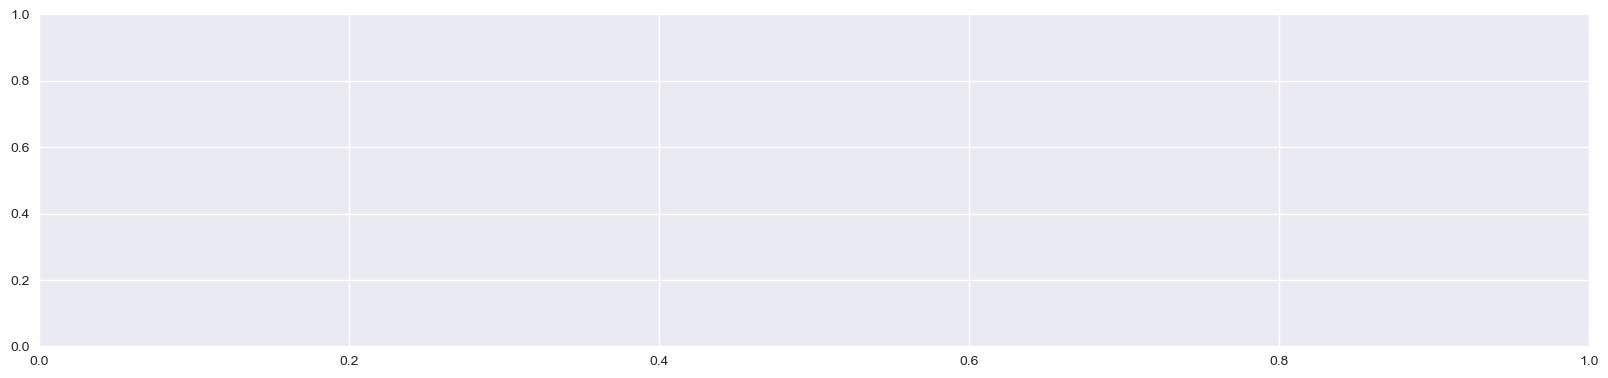

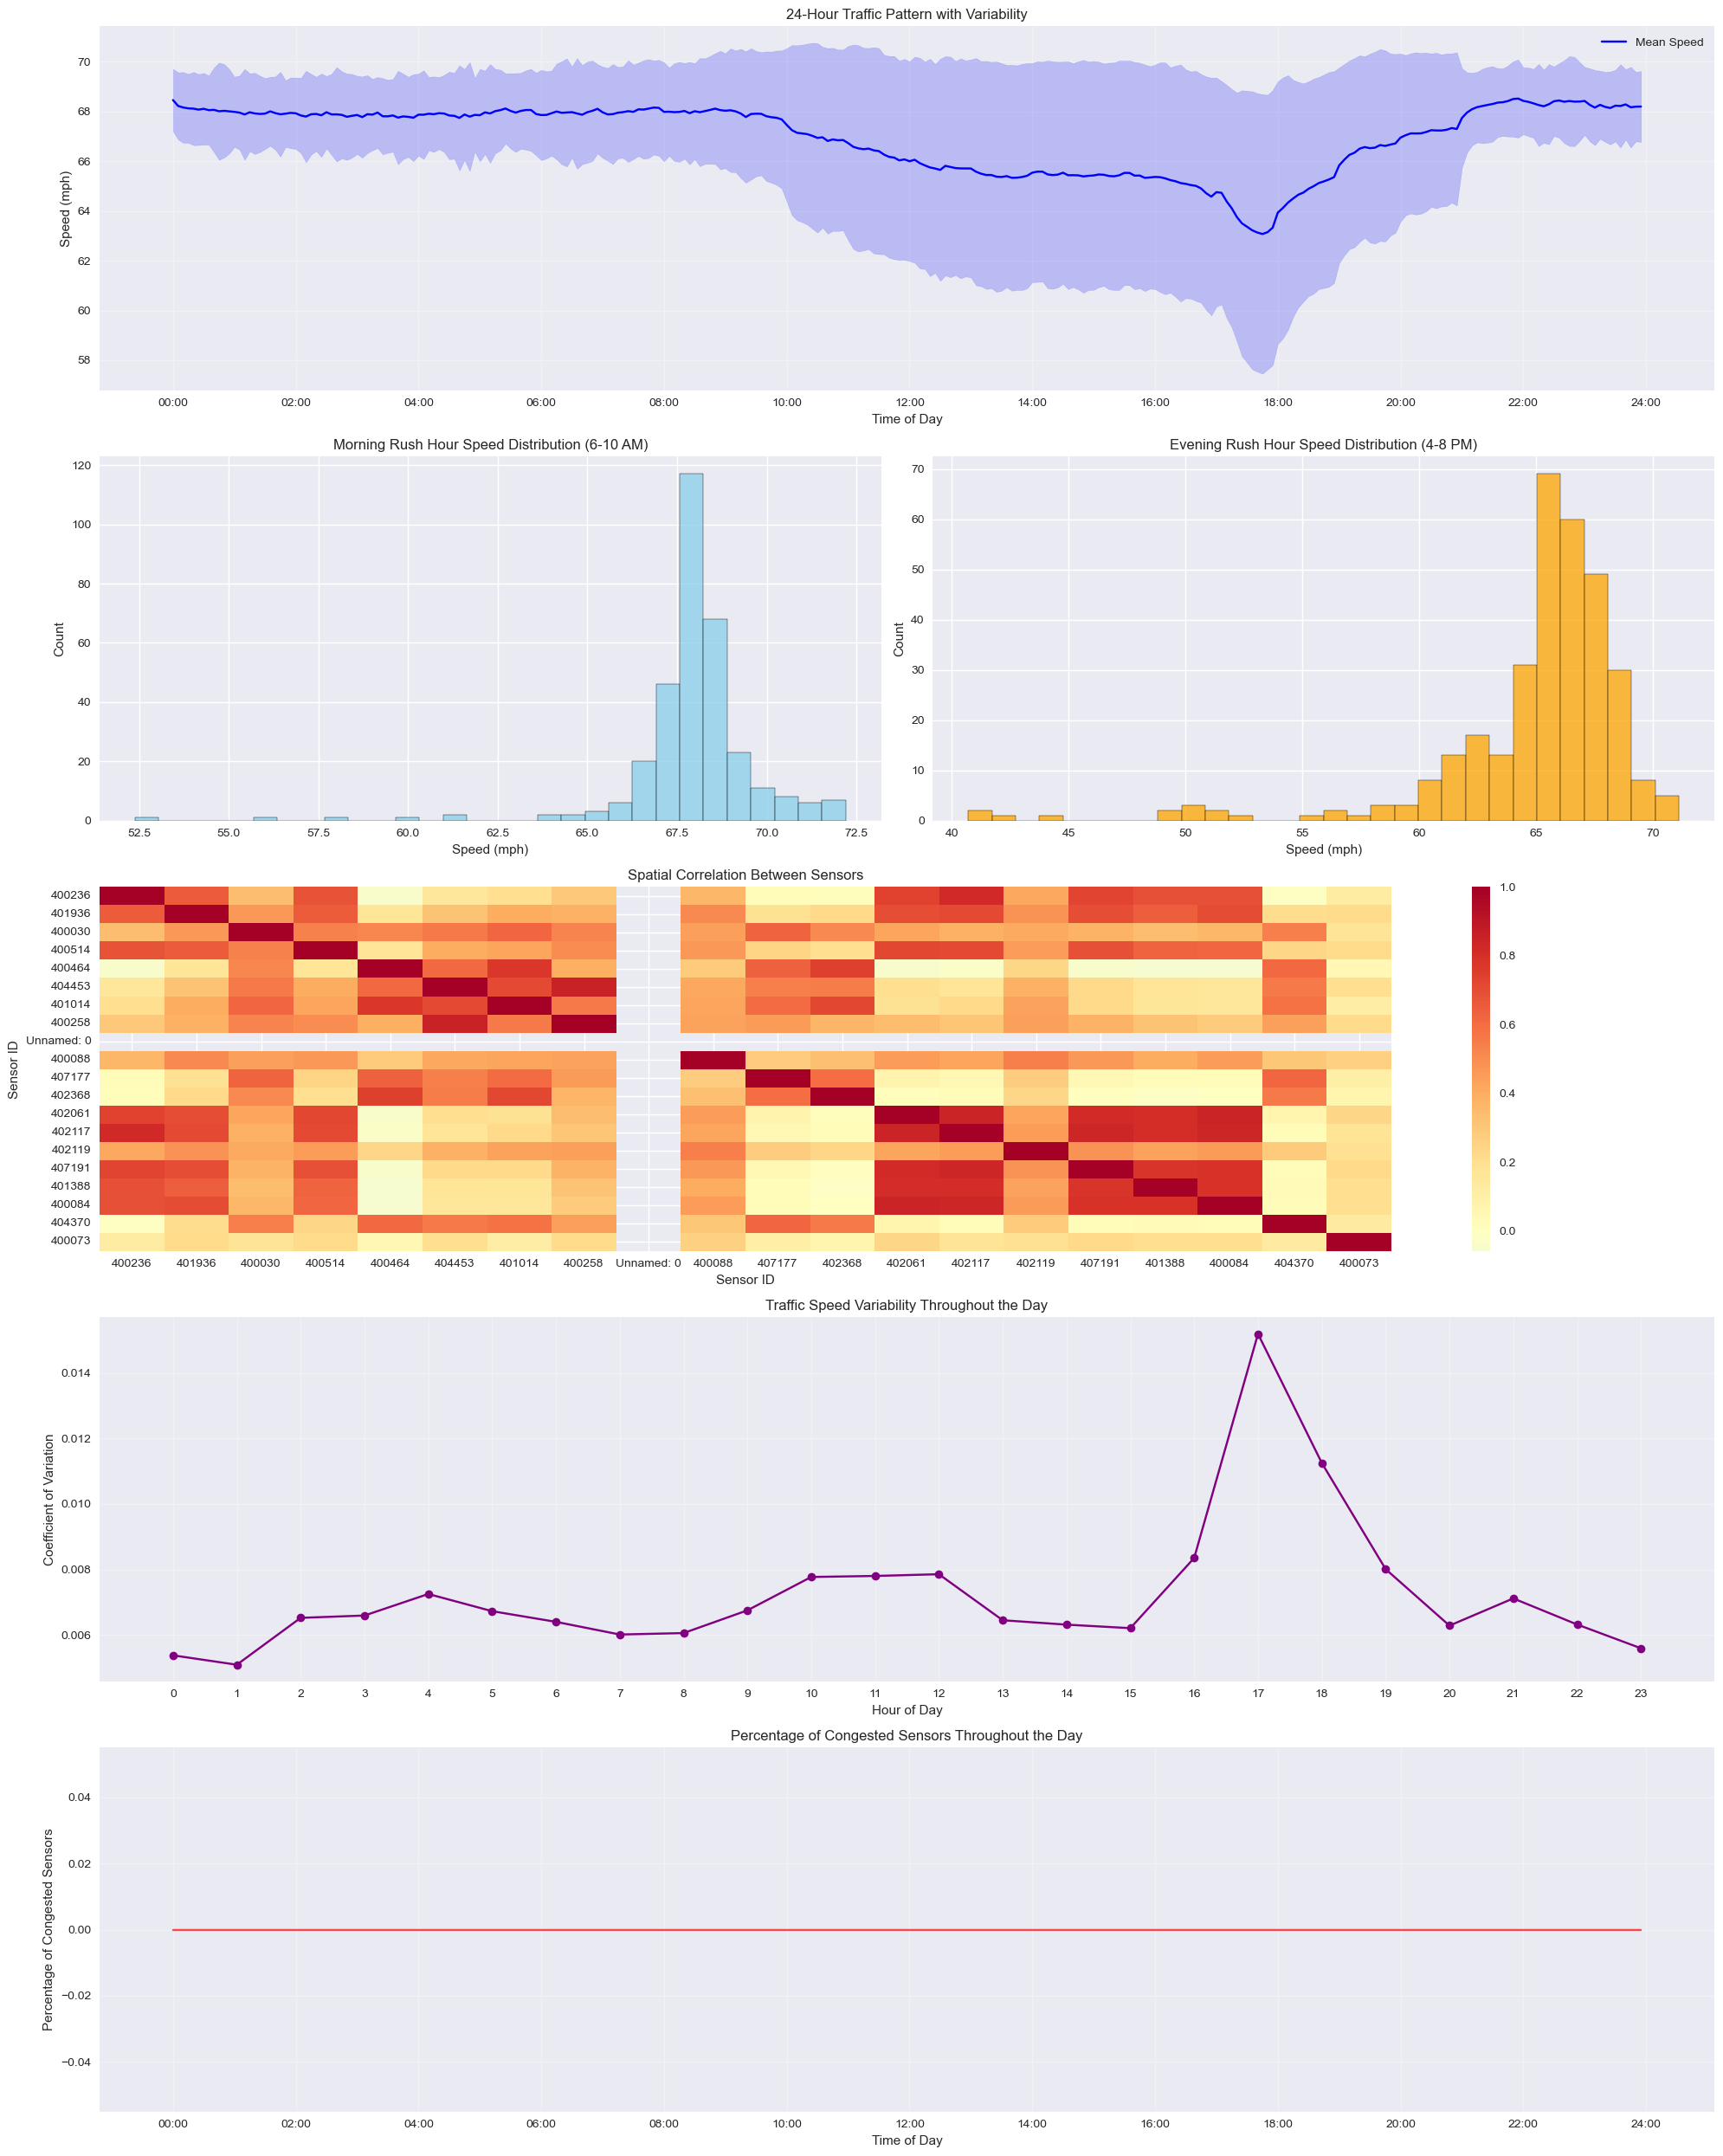


Traffic Pattern Analysis Summary:
--------------------------------------------------

Rush Hour Analysis:
Morning Rush Hour (6-10 AM):
  Average Speed: 68.0 mph
  Speed Variability: 1.9 mph

Evening Rush Hour (4-8 PM):
  Average Speed: 65.0 mph
  Speed Variability: 4.3 mph

Congestion Analysis:
Average Daily Congestion: 0.0% of sensors
Peak Congestion: 0.0% of sensors
Peak Congestion Time: 00:00

Spatial Correlation Analysis:
Average Correlation between sensors: 0.414
Maximum Correlation: 1.000
Minimum Correlation: -0.059

Traffic Variability Analysis:
Most stable hour: Hour 1
Most variable hour: Hour 17


In [ ]:

# 2. Rush Hour Analysis
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# Morning rush (6-10 AM)
morning_rush = df.iloc[72:120, :].mean(axis=0)
# Evening rush (4-8 PM)
evening_rush = df.iloc[192:240, :].mean(axis=0)

sns.histplot(morning_rush, ax=ax2, bins=30, color='skyblue')
ax2.set_title('Morning Rush Hour Speed Distribution (6-10 AM)')
ax2.set_xlabel('Speed (mph)')
ax2.set_ylabel('Count')

sns.histplot(evening_rush, ax=ax3, bins=30, color='orange')
ax3.set_title('Evening Rush Hour Speed Distribution (4-8 PM)')
ax3.set_xlabel('Speed (mph)')
ax3.set_ylabel('Count')

# 3. Spatial Correlations
ax4 = fig.add_subplot(gs[2, :])
# Select 20 random sensors for correlation analysis
random_sensors = np.random.choice(df.columns, size=20, replace=False)
correlation_matrix = df[random_sensors].corr()

sns.heatmap(correlation_matrix, ax=ax4, cmap='RdYlBu_r', center=0)
ax4.set_title('Spatial Correlation Between Sensors')
ax4.set_xlabel('Sensor ID')
ax4.set_ylabel('Sensor ID')

# 4. Traffic Variability Analysis
ax5 = fig.add_subplot(gs[3, :])
# Calculate hourly coefficient of variation
hourly_cv = []
for i in range(0, 288, 12):  # 12 5-minute intervals per hour
    hour_data = df.iloc[i:i+12, :]
    cv = hour_data.std() / hour_data.mean()
    hourly_cv.append(cv.mean())

ax5.plot(hourly_cv, marker='o', color='purple')
ax5.set_title('Traffic Speed Variability Throughout the Day')
ax5.set_xlabel('Hour of Day')
ax5.set_ylabel('Coefficient of Variation')
ax5.set_xticks(range(24))
ax5.grid(True, alpha=0.3)

# 5. Congestion Patterns
ax6 = fig.add_subplot(gs[4, :])

def identify_congestion(speeds, threshold=0.6):
    """Identify congestion when speed drops below 60% of free-flow speed"""
    free_flow = np.percentile(speeds, 85)
    return speeds < (free_flow * threshold)

# Calculate congestion percentage for each time period
congestion_pattern = []
for i in range(288):
    speeds = df.iloc[i, :]
    congestion = identify_congestion(speeds)
    congestion_pattern.append((congestion.sum() / len(speeds)) * 100)

ax6.plot(congestion_pattern, color='red', alpha=0.7)
ax6.set_title('Percentage of Congested Sensors Throughout the Day')
ax6.set_xlabel('Time of Day')
ax6.set_ylabel('Percentage of Congested Sensors')
ax6.set_xticks(np.arange(0, 289, 24))
ax6.set_xticklabels([f'{i:02d}:00' for i in range(0, 25, 2)])
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Statistical Summary
print("\nTraffic Pattern Analysis Summary:")
print("-" * 50)

# Rush Hour Statistics
print("\nRush Hour Analysis:")
print(f"Morning Rush Hour (6-10 AM):")
print(f"  Average Speed: {morning_rush.mean():.1f} mph")
print(f"  Speed Variability: {morning_rush.std():.1f} mph")
print(f"\nEvening Rush Hour (4-8 PM):")
print(f"  Average Speed: {evening_rush.mean():.1f} mph")
print(f"  Speed Variability: {evening_rush.std():.1f} mph")

# Congestion Statistics
print("\nCongestion Analysis:")
avg_congestion = np.mean(congestion_pattern)
peak_congestion = np.max(congestion_pattern)
peak_time = np.argmax(congestion_pattern) * 5  # Convert to minutes
print(f"Average Daily Congestion: {avg_congestion:.1f}% of sensors")
print(f"Peak Congestion: {peak_congestion:.1f}% of sensors")
print(f"Peak Congestion Time: {peak_time//60:02d}:{peak_time%60:02d}")

# Correlation Statistics
print("\nSpatial Correlation Analysis:")
mean_corr = correlation_matrix.mean().mean()
print(f"Average Correlation between sensors: {mean_corr:.3f}")
print(f"Maximum Correlation: {correlation_matrix.max().max():.3f}")
print(f"Minimum Correlation: {correlation_matrix.min().min():.3f}")

# Variability Statistics
print("\nTraffic Variability Analysis:")
print(f"Most stable hour: Hour {np.argmin(hourly_cv)}")
print(f"Most variable hour: Hour {np.arimport seaborn as sns
from scipy import stats
import networkx as nx

# Create figure for multiple subplots
plt.style.use('seaborn-v0_8')  # Updated seaborn style name
fig = plt.figure(figsize=(20, 25))
gs = fig.add_gridspec(5, 2)

# 1. Daily Traffic Patterns
ax1 = fig.add_subplot(gs[0, :])
daily_pattern = df.iloc[:288, :].mean(axis=1)  # Average across all sensors
std_pattern = df.iloc[:288, :].std(axis=1)

ax1.plot(daily_pattern, color='blue', label='Mean Speed')
ax1.fill_between(range(len(daily_pattern)), 
                 daily_pattern - std_pattern, 
                 daily_pattern + std_pattern, 
                 alpha=0.2, color='blue')
ax1.set_title('24-Hour Traffic Pattern with Variability')
ax1.set_xlabel('Time of Day')
ax1.set_ylabel('Speed (mph)')
ax1.set_xticks(np.arange(0, 289, 24))
ax1.set_xticklabels([f'{i:02d}:00' for i in range(0, 25, 2)])
ax1.grid(True, alpha=0.3)
ax1.legend()
gmax(hourly_cv)}")

## 7. Missing Data Analysis and Imputation Techniques

Missing Data Statistics:
Total datapoints: 16937700
Missing datapoints: 3385270
Percentage missing: 19.99%


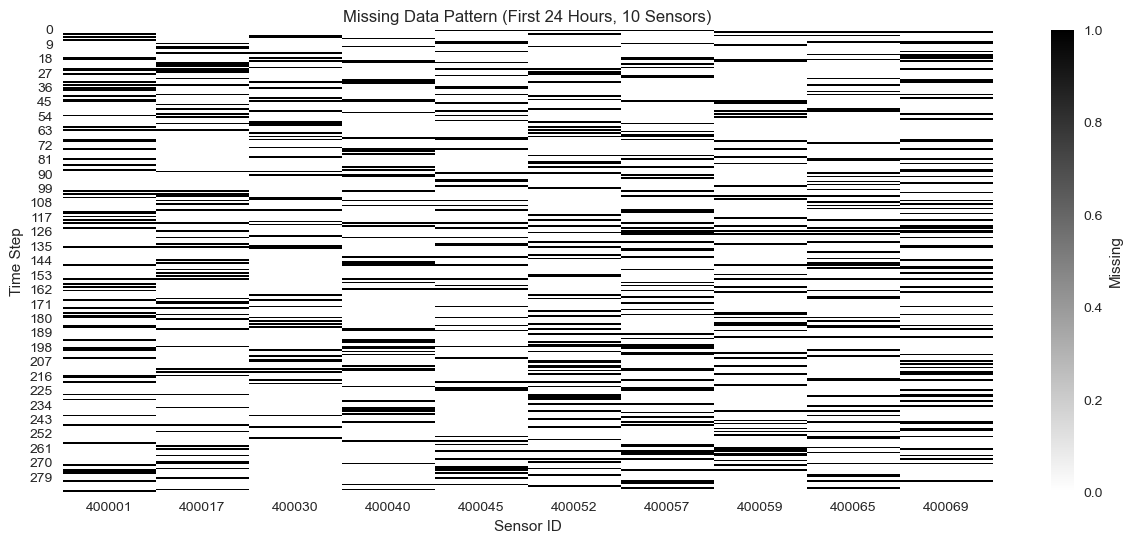

In [31]:
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy of the original data for simulation, excluding the index column
df_missing = df.iloc[:, 1:].copy()  # Skip 'Unnamed: 0' column

# Randomly make some data missing (20% of data)
np.random.seed(42)  # for reproducibility
mask = np.random.random(df_missing.shape) < 0.2
df_missing[mask] = np.nan

# Print missing data statistics
print("Missing Data Statistics:")
print(f"Total datapoints: {df_missing.size}")
print(f"Missing datapoints: {df_missing.isna().sum().sum()}")
print(f"Percentage missing: {(df_missing.isna().sum().sum() / df_missing.size * 100):.2f}%")

# Visualize missing data pattern for first 10 sensors
plt.figure(figsize=(15, 6))
sns.heatmap(df_missing.iloc[:288, :10].isna(), 
            cmap='binary', 
            cbar_kws={'label': 'Missing'})
plt.title('Missing Data Pattern (First 24 Hours, 10 Sensors)')
plt.xlabel('Sensor ID')
plt.ylabel('Time Step')
plt.show()

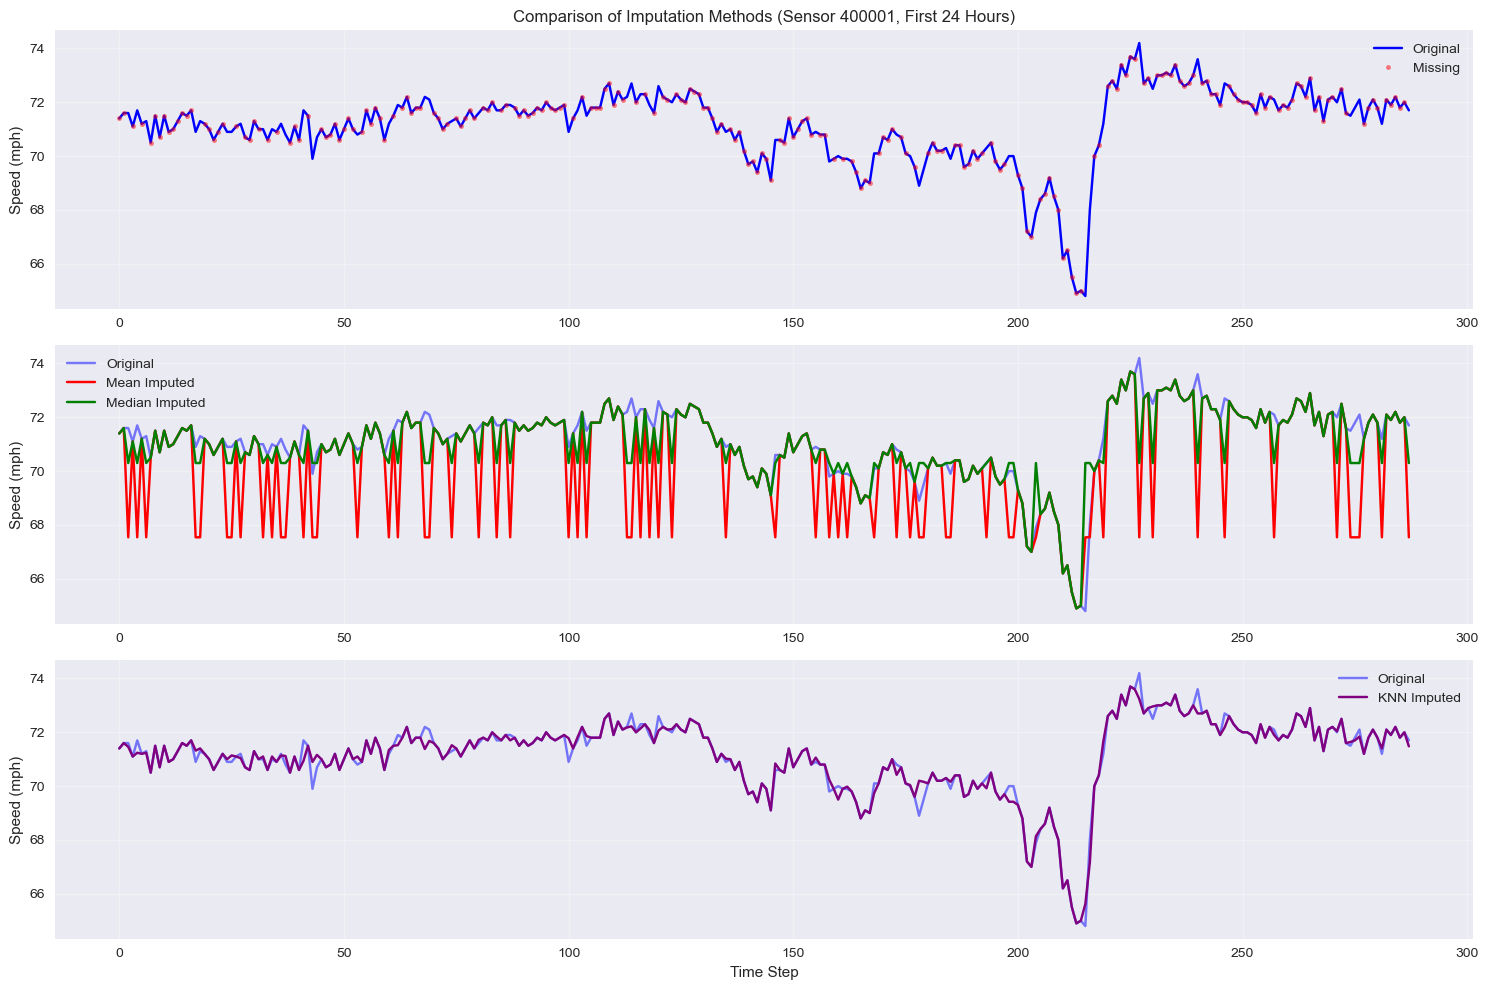


Imputation Error Analysis (RMSE):
----------------------------------------
Mean Imputation Error: 7.96 mph
Median Imputation Error: 8.38 mph
KNN Imputation Error: 1.63 mph

Imputation Method Characteristics:
----------------------------------------
Mean Imputation:
  - Preserves global mean: 0.028 difference
  - Variance ratio: 0.809

Median Imputation:
  - Preserves global median: 0.000 difference
  - Variance ratio: 0.827

KNN Imputation:
  - Preserves global mean: 0.007 difference
  - Variance ratio: 0.988
  - Temporal correlation: 0.979 (original: 0.980)


In [32]:
# 1. Simple Imputation Methods
# Mean imputation
mean_imputer = SimpleImputer(strategy='mean')
df_mean_imputed = pd.DataFrame(
    mean_imputer.fit_transform(df_missing),
    columns=df_missing.columns,
    index=df_missing.index
)

# Median imputation
median_imputer = SimpleImputer(strategy='median')
df_median_imputed = pd.DataFrame(
    median_imputer.fit_transform(df_missing),
    columns=df_missing.columns,
    index=df_missing.index
)

# 2. KNN Imputation
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_missing),
    columns=df_missing.columns,
    index=df_missing.index
)

# Compare imputation methods for one sensor
sensor_id = df_missing.columns[0]  # First sensor
time_range = slice(0, 288)  # First 24 hours

plt.figure(figsize=(15, 10))

# Original Data
plt.subplot(3, 1, 1)
plt.plot(df.iloc[time_range, 1], label='Original', color='blue')  # Skip 'Unnamed: 0' column
plt.plot(df_missing.iloc[time_range, 0], 'r.', label='Missing', alpha=0.5)
plt.title(f'Comparison of Imputation Methods (Sensor {sensor_id}, First 24 Hours)')
plt.ylabel('Speed (mph)')
plt.legend()
plt.grid(True, alpha=0.3)

# Mean and Median Imputation
plt.subplot(3, 1, 2)
plt.plot(df.iloc[time_range, 1], label='Original', color='blue', alpha=0.5)
plt.plot(df_mean_imputed.iloc[time_range, 0], label='Mean Imputed', color='red')
plt.plot(df_median_imputed.iloc[time_range, 0], label='Median Imputed', color='green')
plt.ylabel('Speed (mph)')
plt.legend()
plt.grid(True, alpha=0.3)

# KNN Imputation
plt.subplot(3, 1, 3)
plt.plot(df.iloc[time_range, 1], label='Original', color='blue', alpha=0.5)
plt.plot(df_knn_imputed.iloc[time_range, 0], label='KNN Imputed', color='purple')
plt.xlabel('Time Step')
plt.ylabel('Speed (mph)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate imputation errors
def calculate_imputation_error(original, imputed, missing_mask):
    """Calculate RMSE for imputed values only"""
    return np.sqrt(((original[missing_mask] - imputed[missing_mask]) ** 2).mean())

# Get the mask for missing values
missing_mask = mask[:, 0]  # For first sensor

# Calculate errors for each method
mean_error = calculate_imputation_error(
    df.iloc[:, 1],  # Skip 'Unnamed: 0' column
    df_mean_imputed.iloc[:, 0],
    missing_mask
)

median_error = calculate_imputation_error(
    df.iloc[:, 1],  # Skip 'Unnamed: 0' column
    df_median_imputed.iloc[:, 0],
    missing_mask
)

knn_error = calculate_imputation_error(
    df.iloc[:, 1],  # Skip 'Unnamed: 0' column
    df_knn_imputed.iloc[:, 0],
    missing_mask
)

print("\nImputation Error Analysis (RMSE):")
print("-" * 40)
print(f"Mean Imputation Error: {mean_error:.2f} mph")
print(f"Median Imputation Error: {median_error:.2f} mph")
print(f"KNN Imputation Error: {knn_error:.2f} mph")

# Additional statistics
print("\nImputation Method Characteristics:")
print("-" * 40)
print("Mean Imputation:")
print(f"  - Preserves global mean: {abs(df.iloc[:, 1].mean() - df_mean_imputed.iloc[:, 0].mean()):.3f} difference")
print(f"  - Variance ratio: {df_mean_imputed.iloc[:, 0].var() / df.iloc[:, 1].var():.3f}")

print("\nMedian Imputation:")
print(f"  - Preserves global median: {abs(df.iloc[:, 1].median() - df_median_imputed.iloc[:, 0].median()):.3f} difference")
print(f"  - Variance ratio: {df_median_imputed.iloc[:, 0].var() / df.iloc[:, 1].var():.3f}")

print("\nKNN Imputation:")
print(f"  - Preserves global mean: {abs(df.iloc[:, 1].mean() - df_knn_imputed.iloc[:, 0].mean()):.3f} difference")
print(f"  - Variance ratio: {df_knn_imputed.iloc[:, 0].var() / df.iloc[:, 1].var():.3f}")
print(f"  - Temporal correlation: {df_knn_imputed.iloc[:, 0].autocorr():.3f} (original: {df.iloc[:, 1].autocorr():.3f})")

## 8. Advanced Missing Data Patterns and Imputation Analysis

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to create different missing patterns
def create_missing_patterns(data, pattern_type='random', missing_ratio=0.2):
    data_missing = data.copy()
    
    if pattern_type == 'random':
        # Random missing values
        mask = np.random.random(data.shape) < missing_ratio
        
    elif pattern_type == 'sensor_failure':
        # Simulate complete sensor failures
        mask = np.zeros_like(data, dtype=bool)
        n_sensors = int(data.shape[1] * missing_ratio)
        failed_sensors = np.random.choice(data.shape[1], n_sensors, replace=False)
        mask[:, failed_sensors] = True
        
    elif pattern_type == 'time_blocks':
        # Simulate missing blocks of time
        mask = np.zeros_like(data, dtype=bool)
        block_size = 12  # 1-hour blocks
        n_blocks = int((data.shape[0] * missing_ratio) / block_size)
        for _ in range(n_blocks):
            start = np.random.randint(0, data.shape[0] - block_size)
            sensors = np.random.randint(0, data.shape[1], size=5)  # Random 5 sensors
            mask[start:start+block_size, sensors] = True
            
    data_missing[mask] = np.nan
    return data_missing, mask

# Create different missing patterns for the first day of data (excluding index column)
patterns = ['random', 'sensor_failure', 'time_blocks']
data_subset = df.iloc[:288, 1:21]  # First day, 20 sensors
missing_dfs = {}
masks = {}

for pattern in patterns:
    missing_dfs[pattern], masks[pattern] = create_missing_patterns(
        data_subset,
        pattern_type=pattern
    )

# Visualize different missing patterns
fig, axes = plt.subplots(len(patterns), 1, figsize=(15, 12))
fig.suptitle('Different Types of Missing Data Patterns', fontsize=16)

for ax, pattern in zip(axes, patterns):
    sns.heatmap(missing_dfs[pattern].isna(), 
                cmap='binary',
                cbar=False,
                ax=ax)
    ax.set_title(f'{pattern.replace("_", " ").title()} Pattern')
    ax.set_xlabel('Sensor ID')
    ax.set_ylabel('Time Step')

plt.tight_layout()
plt.show()

# Apply imputation methods to each pattern
imputation_methods = {
    'mean': SimpleImputer(strategy='mean'),
    'median': SimpleImputer(strategy='median'),
    'knn': KNNImputer(n_neighbors=5)
}

# Calculate imputation metrics
def calculate_metrics(original, imputed, mask):
    """Calculate various metrics for imputation quality"""
    rmse = np.sqrt(((original[mask] - imputed[mask]) ** 2).mean())
    mae = np.abs(original[mask] - imputed[mask]).mean()
    correlation = stats.pearsonr(original[mask], imputed[mask])[0]
    return rmse, mae, correlation

# Store results
results = []

for pattern in patterns:
    original = data_subset
    missing_data = missing_dfs[pattern]
    mask = masks[pattern]
    
    for method_name, imputer in imputation_methods.items():
        imputed = pd.DataFrame(
            imputer.fit_transform(missing_data),
            columns=missing_data.columns,
            index=missing_data.index
        )
        
        rmse, mae, corr = calculate_metrics(original, imputed, mask)
        results.append({
            'Pattern': pattern,
            'Method': method_name,
            'RMSE': rmse,
            'MAE': mae,
            'Correlation': corr
        })

# Create results DataFrame
results_df = pd.DataFrame(results)

# Plot comparison metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics = ['RMSE', 'MAE', 'Correlation']

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=results_df,
        x='Pattern',
        y=metric,
        hue='Method',
        ax=ax
    )
    ax.set_title(f'{metric} by Pattern and Method')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\nDetailed Imputation Analysis:")
print("-" * 50)
for pattern in patterns:
    print(f"\n{pattern.replace('_', ' ').title()} Pattern:")
    pattern_results = results_df[results_df['Pattern'] == pattern]
    
    print("\nBest method by metric:")
    for metric in ['RMSE', 'MAE', 'Correlation']:
        if metric != 'Correlation':
            best_idx = pattern_results[metric].idxmin()
        else:
            best_idx = pattern_results[metric].idxmax()
            
        best_method = pattern_results.loc[best_idx]
        print(f"{metric}: {best_method['Method']} "
              f"(value: {best_method[metric]:.3f})")

# Visualize temporal patterns
plt.figure(figsize=(15, 8))
pattern = 'time_blocks'  # Most interesting pattern to visualize
sensor_id = data_subset.columns[0]  # First sensor

plt.plot(data_subset[sensor_id], 
         label='Original', 
         color='blue', 
         alpha=0.5)

plt.plot(missing_dfs[pattern][sensor_id], 
         'r.', 
         label='Missing', 
         alpha=0.5)

for method_name, imputer in imputation_methods.items():
    imputed = pd.DataFrame(
        imputer.fit_transform(missing_dfs[pattern]),
        columns=missing_dfs[pattern].columns,
        index=missing_dfs[pattern].index
    )
    plt.plot(imputed[sensor_id], 
             label=f'{method_name.title()} Imputed',
             alpha=0.7)

plt.title('Comparison of Imputation Methods for Time Block Missing Pattern')
plt.xlabel('Time Step')
plt.ylabel('Speed (mph)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nRecommendations:")
print("-" * 50)
print("1. For random missing values: ", 
      results_df[results_df['Pattern'] == 'random']['Method']\
      [results_df[results_df['Pattern'] == 'random']['RMSE'].idxmin()])
print("2. For sensor failures: ",
      results_df[results_df['Pattern'] == 'sensor_failure']['Method']\
      [results_df[results_df['Pattern'] == 'sensor_failure']['RMSE'].idxmin()])
print("3. For missing time blocks: ",
      results_df[results_df['Pattern'] == 'time_blocks']['Method']\
      [results_df[results_df['Pattern'] == 'time_blocks']['RMSE'].idxmin()])